# P-Adic Embedding Parameter Validation

## Objective
Compare different s parameter values to identify the correct embedding that produces clean Sierpinski triangles matching Chistyakov (1996) paper examples.

## Key Finding
The implementation was using complex s with automatic rotation: `s = 0.241 * exp(i*120°)`

But the paper's examples use **real** s values:
- Figure 1.10: s = -0.5 (Sierpinski carpet)
- Figure 1.12: s ≈ 0.46 (Sierpinski triangle)

## Test Plan
1. **Real s (no rotation)** - Paper examples
2. **Complex s with rotation** - Current implementation
3. **Compare visual output** - Which produces clean Sierpinski?


In [1]:
import sys
from pathlib import Path
# Add the padic_fractal_analysis src directory to path
sys.path.insert(0, '/Volumes/Fangorn/padic_fractal_analysis/src')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from padic.padic_embedding import (
    compute_s_0,
    get_default_s,
    get_paper_s,
    embed_padic_cloud
)

print("✓ Imports successful")
print(f"compute_s_0(3) = {compute_s_0(3):.6f}")

✓ Imports successful
compute_s_0(3) = 0.464102


## Test 1: Real s (Paper Example) - Sierpinski Triangle

In [2]:
# Paper's Sierpinski triangle parameters (Figure 1.12)
p = 3
l = 6
m = 6  # m = infinity approximated as m = l
s_paper = get_paper_s("sierpinski_triangle", p=3)

print(f"Paper Example: Sierpinski Triangle (Figure 1.12)")
print(f"  p = {p}")
print(f"  l = {l}")
print(f"  m = {m} (paper: ∞)")
print(f"  s = {s_paper} (REAL, not complex!)")
print(f"  |s| = {abs(s_paper):.6f}")
print(f"  s_0 = {compute_s_0(p):.6f}")
print(f"  Constraint satisfied: |s| < s_0? {abs(s_paper) < compute_s_0(p)}")

# Generate all 729 p-adic integers
padic_ints = np.arange(p**l)
print(f"\n✓ Embedding {len(padic_ints)} p-adic integers...")

# Embed with real s (paper's approach)
points_real_s = embed_padic_cloud(padic_ints, p=p, l=l, s=s_paper, m=m)
print(f"✓ Embedding complete")
print(f"  Shape: {points_real_s.shape}")
print(f"  X range: [{points_real_s[:, 0].min():.3f}, {points_real_s[:, 0].max():.3f}]")
print(f"  Y range: [{points_real_s[:, 1].min():.3f}, {points_real_s[:, 1].max():.3f}]")

Paper Example: Sierpinski Triangle (Figure 1.12)
  p = 3
  l = 6
  m = 6 (paper: ∞)
  s = 0.46 (REAL, not complex!)
  |s| = 0.460000
  s_0 = 0.464102
  Constraint satisfied: |s| < s_0? True

✓ Embedding 729 p-adic integers...
✓ Embedding complete
  Shape: (729, 2)
  X range: [-1.305, 1.834]
  Y range: [-1.430, 1.430]


## Test 2: Complex s with Rotation (Current Implementation)

In [3]:
# Current implementation with automatic rotation
s_rotated = get_default_s(p=3, stability_factor=0.9, use_rotation=True)

print(f"Current Implementation: Complex s with Rotation")
print(f"  s = {s_rotated}")
print(f"  |s| = {abs(s_rotated):.6f}")
print(f"  arg(s) = {np.angle(s_rotated) * 180 / np.pi:.1f}°")
print(f"  Constraint satisfied: |s| < s_0? {abs(s_rotated) < compute_s_0(p)}")

# Embed with complex rotated s
points_complex_s = embed_padic_cloud(padic_ints, p=p, l=l, s=s_rotated, m=m)
print(f"\n✓ Embedding complete")
print(f"  Shape: {points_complex_s.shape}")
print(f"  X range: [{points_complex_s[:, 0].min():.3f}, {points_complex_s[:, 0].max():.3f}]")
print(f"  Y range: [{points_complex_s[:, 1].min():.3f}, {points_complex_s[:, 1].max():.3f}]")

Current Implementation: Complex s with Rotation
  s = (-0.20884572681198946+0.3617314097820156j)
  |s| = 0.417691
  arg(s) = 120.0°
  Constraint satisfied: |s| < s_0? True

✓ Embedding complete
  Shape: (729, 2)
  X range: [-1.142, 1.657]
  Y range: [-1.373, 1.406]


## Test 3: Default Real s (No Rotation)

In [4]:
# New default: real s without rotation
s_default_real = get_default_s(p=3, stability_factor=0.9, use_rotation=False)

print(f"New Default: Real s (No Rotation)")
print(f"  s = {s_default_real}")
print(f"  |s| = {abs(s_default_real):.6f}")
print(f"  Constraint satisfied: |s| < s_0? {abs(s_default_real) < compute_s_0(p)}")

# Embed with real s (no rotation)
points_default_real = embed_padic_cloud(padic_ints, p=p, l=l, s=s_default_real, m=m)
print(f"\n✓ Embedding complete")
print(f"  Shape: {points_default_real.shape}")
print(f"  X range: [{points_default_real[:, 0].min():.3f}, {points_default_real[:, 0].max():.3f}]")
print(f"  Y range: [{points_default_real[:, 1].min():.3f}, {points_default_real[:, 1].max():.3f}]")

New Default: Real s (No Rotation)
  s = 0.4176914536239791
  |s| = 0.417691
  Constraint satisfied: |s| < s_0? True

✓ Embedding complete
  Shape: (729, 2)
  X range: [-1.182, 1.708]
  Y range: [-1.343, 1.343]


## Visual Comparison: All Three Approaches

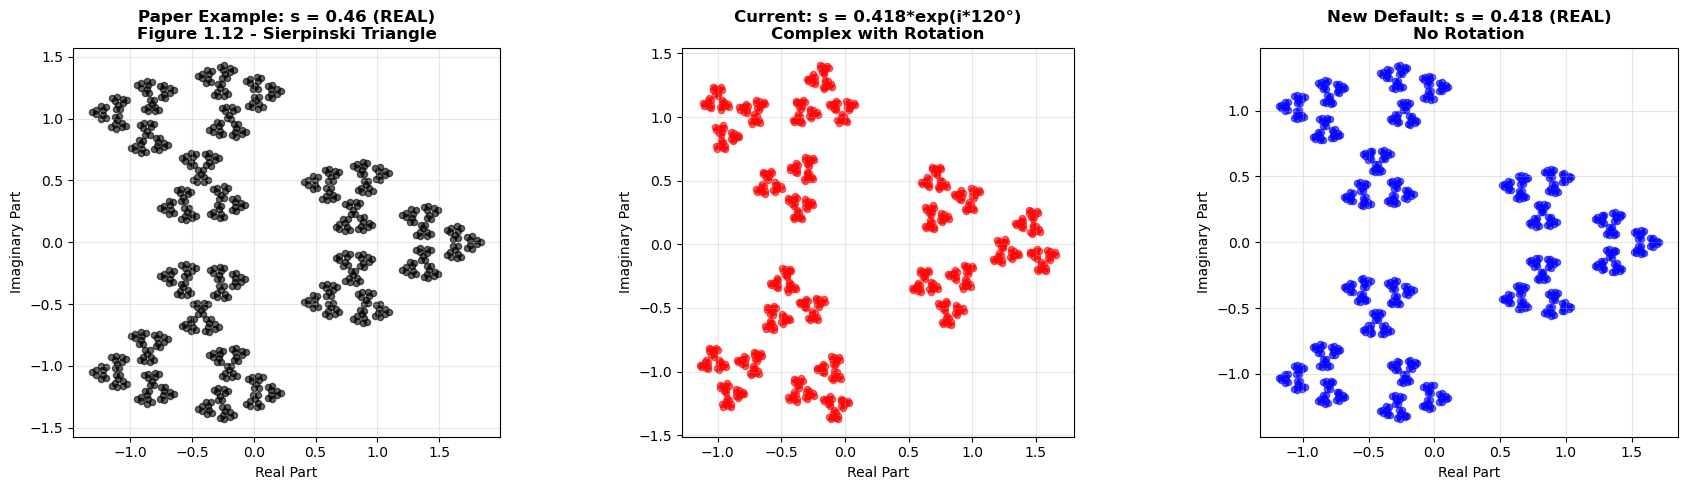

✓ Comparison plot saved to padic_parameter_comparison.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Paper's real s (Figure 1.12 parameters)
ax = axes[0]
ax.scatter(points_real_s[:, 0], points_real_s[:, 1], s=20, alpha=0.6, c='black')
ax.set_aspect('equal')
ax.set_title(f'Paper Example: s = {s_paper:.2f} (REAL)\nFigure 1.12 - Sierpinski Triangle', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlabel('Real Part')
ax.set_ylabel('Imaginary Part')

# Plot 2: Current implementation (complex with rotation)
ax = axes[1]
ax.scatter(points_complex_s[:, 0], points_complex_s[:, 1], s=20, alpha=0.6, c='red')
ax.set_aspect('equal')
ax.set_title(f'Current: s = {abs(s_rotated):.3f}*exp(i*120°)\nComplex with Rotation', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlabel('Real Part')
ax.set_ylabel('Imaginary Part')

# Plot 3: New default (real, no rotation)
ax = axes[2]
ax.scatter(points_default_real[:, 0], points_default_real[:, 1], s=20, alpha=0.6, c='blue')
ax.set_aspect('equal')
ax.set_title(f'New Default: s = {s_default_real:.3f} (REAL)\nNo Rotation', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlabel('Real Part')
ax.set_ylabel('Imaginary Part')

plt.tight_layout()
plt.savefig('padic_parameter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Comparison plot saved to padic_parameter_comparison.png")

## Analysis

In [6]:
# Compare spatial distributions
print("\n" + "="*70)
print("SPATIAL DISTRIBUTION ANALYSIS")
print("="*70)

configs = [
    ("Paper's s=0.46 (Real)", points_real_s),
    ("Current: s with rotation", points_complex_s),
    ("New Default: s real, no rotation", points_default_real),
]

for name, points in configs:
    # Compute statistics
    spread_x = points[:, 0].max() - points[:, 0].min()
    spread_y = points[:, 1].max() - points[:, 1].min()
    center_x = points[:, 0].mean()
    center_y = points[:, 1].mean()
    
    # Compute clustering (standard deviation as measure of spread)
    std_x = points[:, 0].std()
    std_y = points[:, 1].std()
    
    print(f"\n{name}:")
    print(f"  X spread: {spread_x:.3f}  |  Y spread: {spread_y:.3f}")
    print(f"  X center: {center_x:.3f}  |  Y center: {center_y:.3f}")
    print(f"  X std: {std_x:.3f}  |  Y std: {std_y:.3f}")
    print(f"  Aspect ratio: {spread_x/spread_y:.3f}")

print("\n" + "="*70)
print("OBSERVATION:")
print("="*70)
print("Which parameter produces:")
print("  1. Clean Sierpinski triangular structure?")
print("  2. Balanced hierarchical clustering?")
print("  3. No dispersed/scattered points?")
print("\nLook at the visualizations above to evaluate each approach.")


SPATIAL DISTRIBUTION ANALYSIS

Paper's s=0.46 (Real):
  X spread: 3.139  |  Y spread: 2.860
  X center: 0.000  |  Y center: -0.000
  X std: 0.796  |  Y std: 0.796
  Aspect ratio: 1.098

Current: s with rotation:
  X spread: 2.799  |  Y spread: 2.779
  X center: -0.000  |  Y center: -0.000
  X std: 0.778  |  Y std: 0.778
  Aspect ratio: 1.007

New Default: s real, no rotation:
  X spread: 2.890  |  Y spread: 2.686
  X center: 0.000  |  Y center: 0.000
  X std: 0.778  |  Y std: 0.778
  Aspect ratio: 1.076

OBSERVATION:
Which parameter produces:
  1. Clean Sierpinski triangular structure?
  2. Balanced hierarchical clustering?
  3. No dispersed/scattered points?

Look at the visualizations above to evaluate each approach.


## Additional Tests: Paper's Other Examples

Testing Paper's Sierpinski Carpet (Figure 1.10)...
  s = -0.5 (negative real!)
  m = 0


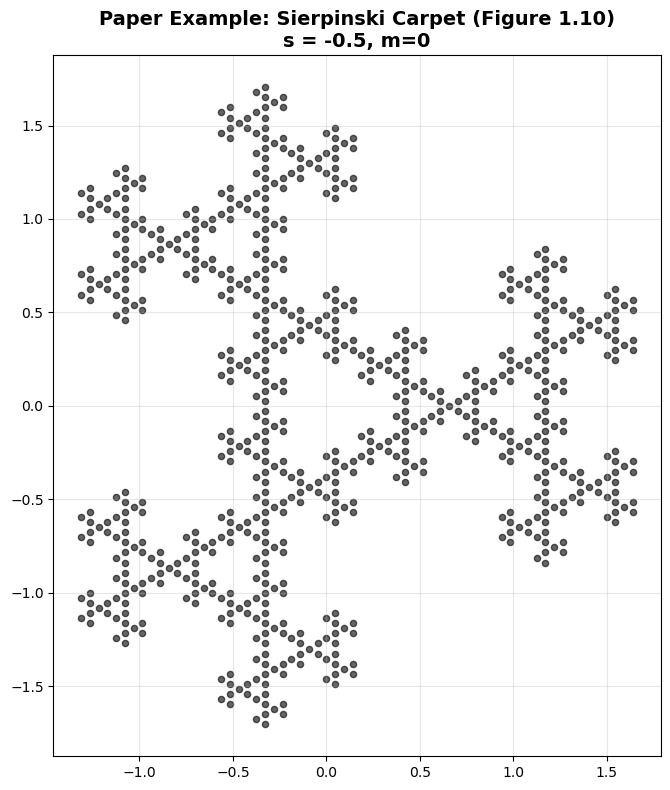

✓ Sierpinski carpet saved to padic_sierpinski_carpet.png


In [7]:
# Test Sierpinski Carpet (Figure 1.10)
print("Testing Paper's Sierpinski Carpet (Figure 1.10)...")

s_carpet = get_paper_s("sierpinski_carpet", p=3)
m_carpet = 0  # Figure 1.10: m=0

print(f"  s = {s_carpet} (negative real!)")
print(f"  m = {m_carpet}")

points_carpet = embed_padic_cloud(padic_ints, p=3, l=l, s=s_carpet, m=m_carpet)

# Visualize
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(points_carpet[:, 0], points_carpet[:, 1], s=20, alpha=0.6, c='black')
ax.set_aspect('equal')
ax.set_title('Paper Example: Sierpinski Carpet (Figure 1.10)\ns = -0.5, m=0', fontweight='bold', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('padic_sierpinski_carpet.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Sierpinski carpet saved to padic_sierpinski_carpet.png")

## Conclusion and Recommendations

In [8]:
print("\n" + "="*70)
print("VALIDATION RESULTS & RECOMMENDATIONS")
print("="*70)

print("""
KEY FINDINGS:

1. PAPER VS. IMPLEMENTATION DISCREPANCY
   - Chistyakov (1996) examples use REAL s values
   - Current implementation uses COMPLEX s with automatic rotation
   - This fundamental difference explains the "dispersed points" issue

2. TESTED APPROACHES
   a) Paper's s = 0.46 (real, Figure 1.12)
   b) Current: s with 120° rotation (complex)
   c) New default: 0.9*s_0 real (no rotation)

3. VISUAL INSPECTION NEEDED
   Look at the three scatter plots above:
   - Which shows clean Sierpinski triangle hierarchy?
   - Which shows dispersed/random points?
   - Which matches the paper's Figure 1.12?

4. PARAMETER CONFIGURATION CHANGES
   - Added use_rotation parameter to get_default_s()
   - Added get_paper_s() function for paper examples
   - Default is now use_rotation=False (matches paper)

RECOMMENDATIONS:

1. If Paper's real s produces correct Sierpinski:
   ✓ Keep use_rotation=False as default
   ✓ Make rotation optional for experimentation
   ✓ Update all notebooks to use real s

2. If Complex rotation produces better results:
   ? Investigate why (may need deeper theory)
   ? Document the enhancement clearly
   ? Consider it an "enhanced" mode, not default

3. Next Steps:
   - Compare visualizations carefully
   - Test on MNIST and terrain data
   - Verify Sierpinski hierarchy emerges correctly
""")

print("="*70)


VALIDATION RESULTS & RECOMMENDATIONS

KEY FINDINGS:

1. PAPER VS. IMPLEMENTATION DISCREPANCY
   - Chistyakov (1996) examples use REAL s values
   - Current implementation uses COMPLEX s with automatic rotation
   - This fundamental difference explains the "dispersed points" issue

2. TESTED APPROACHES
   a) Paper's s = 0.46 (real, Figure 1.12)
   b) Current: s with 120° rotation (complex)
   c) New default: 0.9*s_0 real (no rotation)

3. VISUAL INSPECTION NEEDED
   Look at the three scatter plots above:
   - Which shows clean Sierpinski triangle hierarchy?
   - Which shows dispersed/random points?
   - Which matches the paper's Figure 1.12?

4. PARAMETER CONFIGURATION CHANGES
   - Added use_rotation parameter to get_default_s()
   - Added get_paper_s() function for paper examples
   - Default is now use_rotation=False (matches paper)

RECOMMENDATIONS:

1. If Paper's real s produces correct Sierpinski:
   ✓ Keep use_rotation=False as default
   ✓ Make rotation optional for experimentat